In [1]:
# Numpy and xarray are always necessary
import numpy as np
import xarray as xr

# pyplot needed to plot the dataset, but animation only needed much further down.
from matplotlib import pyplot as plt, animation
%matplotlib inline

# This is needed to display graphics calculated outside of jupyter notebook
from IPython.display import HTML, display

# Also, in case we haven't created it yet, make sure that we have a directory for images and videos
! test -d ../images/Python_Animation && rm -rf ../images/Python_Animation/* || mkdir -p ../images/Python_Animation

In [2]:
ds = xr.tutorial.open_dataset('air_temperature')
ds

<xarray.Dataset>
Dimensions:  (lat: 25, lon: 53, time: 2920)
Coordinates:
  * lat      (lat) float32 75.0 72.5 70.0 67.5 65.0 ... 25.0 22.5 20.0 17.5 15.0
  * lon      (lon) float32 200.0 202.5 205.0 207.5 ... 322.5 325.0 327.5 330.0
  * time     (time) datetime64[ns] 2013-01-01 ... 2014-12-31T18:00:00
Data variables:
    air      (time, lat, lon) float32 ...
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

In [3]:
tas=ds.air
tas = tas - 273.15
tas.attrs['units'] = 'degC'
tas.attrs['long_name'] = "Air Temperature"

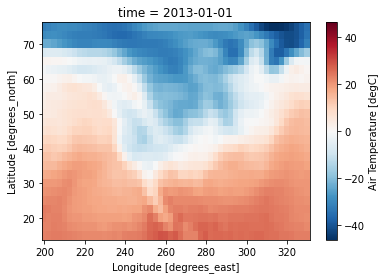

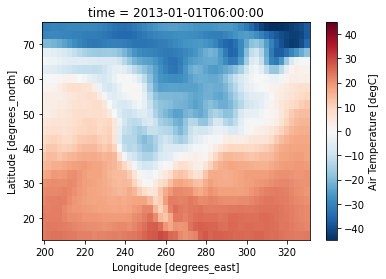

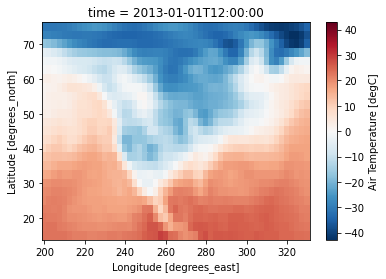

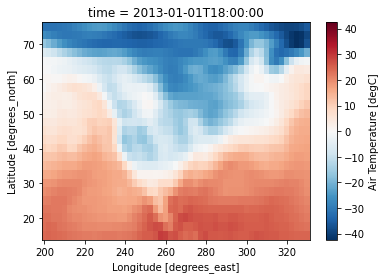

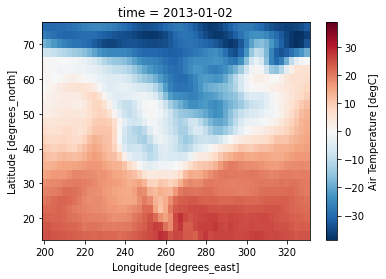

In [4]:
for i in range(5):
    tas[i,:,:].plot(figsize=(6,4))
    plt.show()
    plt.close()

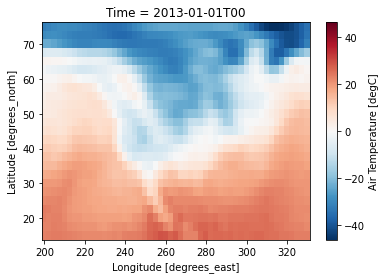

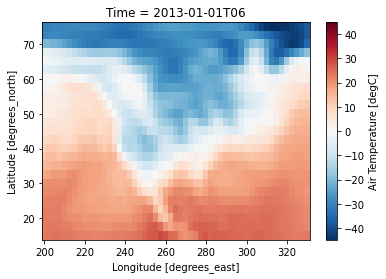

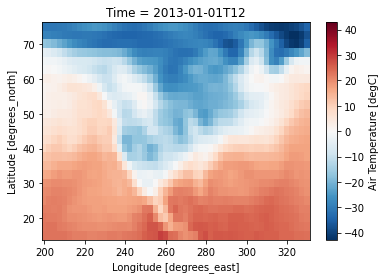

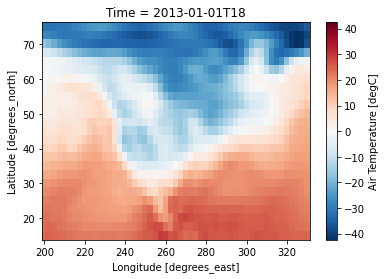

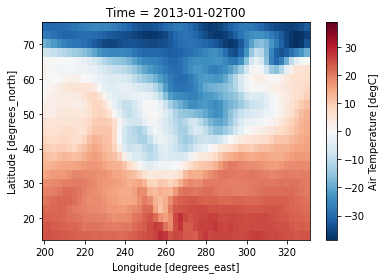

In [5]:
for i in range(5):
    tas[i,:,:].plot(figsize=(6,4))
    plt.title("Time = " + str(tas.coords['time'].values[i])[:13])
    plt.show()
    plt.close()

In [6]:
for i in range(40):
    tas[i,:,:].plot(
        figsize = (12,6)      # We'll make it a bit bigger
    )
    plt.title("Time = " + str(tas.coords['time'].values[i])[:13])
    plt.savefig(f"../images/Python_Animation/Python_Animation_01_frame_{i:04}.png")
    plt.close()

In [7]:
!ls ../images/Python_Animation/

Python_Animation_01_frame_0000.png  Python_Animation_01_frame_0020.png
Python_Animation_01_frame_0001.png  Python_Animation_01_frame_0021.png
Python_Animation_01_frame_0002.png  Python_Animation_01_frame_0022.png
Python_Animation_01_frame_0003.png  Python_Animation_01_frame_0023.png
Python_Animation_01_frame_0004.png  Python_Animation_01_frame_0024.png
Python_Animation_01_frame_0005.png  Python_Animation_01_frame_0025.png
Python_Animation_01_frame_0006.png  Python_Animation_01_frame_0026.png
Python_Animation_01_frame_0007.png  Python_Animation_01_frame_0027.png
Python_Animation_01_frame_0008.png  Python_Animation_01_frame_0028.png
Python_Animation_01_frame_0009.png  Python_Animation_01_frame_0029.png
Python_Animation_01_frame_0010.png  Python_Animation_01_frame_0030.png
Python_Animation_01_frame_0011.png  Python_Animation_01_frame_0031.png
Python_Animation_01_frame_0012.png  Python_Animation_01_frame_0032.png
Python_Animation_01_frame_0013.png  Python_Animation_01_frame_0033.png
Python

In [8]:
!convert ../images/Python_Animation/Python_Animation_01_frame*png ../images/Python_Animation/Python_Animation_01.gif
display(HTML("<img src='../images/Python_Animation/Python_Animation_01.gif' />"))

In [9]:
for i in range(40):
    tas[i,:,:].plot(
        figsize = (12,6),
        vmin=-40, vmax=40  # Minimum and Maximum values
    )
    plt.title("Time = " + str(tas.coords['time'].values[i])[:13])
    plt.savefig(f"../images/Python_Animation/Python_Animation_02_frame_{i:04}.png")
    plt.close()

In [10]:
!convert ../images/Python_Animation/Python_Animation_02_frame*.png ../images/Python_Animation/Python_Animation_02.gif
display(HTML("<img src='../images/Python_Animation/Python_Animation_02.gif' />"))

In [11]:
for i in range(40):
    tas[i,:,:].plot(
        figsize = (12,6),
        vmin=-40, vmax=40,
        cmap='coolwarm',    # Change the colormap back to 'bwr'
        cbar_kwargs={
            'extend':'neither' # Don't extend the colorbar in either direction. Other possibilities
                               # would be 'both', 'min', or 'max'
        }
    )
    plt.title("Time = " + str(tas.coords['time'].values[i])[:13])
    plt.savefig(f"../images/Python_Animation/Python_Animation_03_frame_{i:04}.png")
    plt.close()

In [12]:
!convert ../images/Python_Animation/Python_Animation_03_frame*.png ../images/Python_Animation/Python_Animation_03.gif
display(HTML("<img src='../images/Python_Animation/Python_Animation_03.gif' />"))

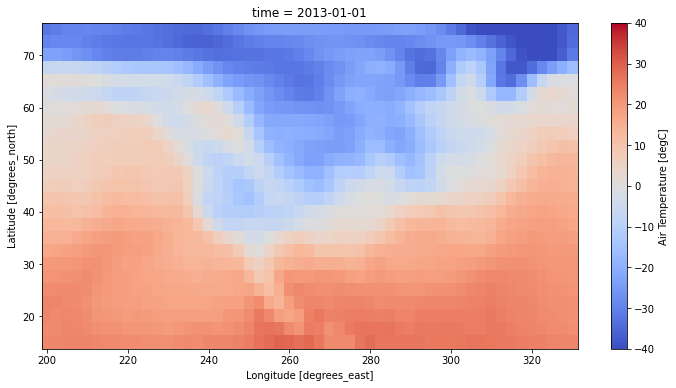

In [17]:
# Get a handle on the figure and the axes
fig, ax = plt.subplots(figsize=(12,6))
tas=ds.air
tas = tas - 273.15
tas.attrs['units'] = 'degC'
tas.attrs['long_name'] = "Air Temperature"
# Plot the initial frame. 
cax = tas[0,:,:].plot(
    add_colorbar=True,
    cmap='coolwarm',
    vmin=-40, vmax=40,
    cbar_kwargs={
        'extend':'neither'
    }
)

# Next we need to create a function that updates the values for the colormesh, as well as the title.
def animate(frame):
    cax.set_array(tas[frame,:,:].values.flatten())
    ax.set_title("Time = " + str(tas.coords['time'].values[frame])[:200])

# Finally, we use the animation module to create the animation.
ani = animation.FuncAnimation(
    fig,             # figure
    animate,         # name of the function above
    frames=12,       # Could also be iterable or list
    interval=200     # ms between frames
)

In [18]:
HTML(ani.to_jshtml())